# California Housing EDA

This notebook loads the `fetch_california_housing` dataset and focuses on a first exploratory data analysis of the target and the main numerical features.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

rename_map = {
    "MedInc": "median_income",
    "HouseAge": "house_age",
    "AveRooms": "rooms_per_household",
    "AveBedrms": "bedrooms_per_household",
    "Population": "total_population",
    "AveOccup": "population_per_household",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "MedHouseVal": "median_house_value",
}

housing = fetch_california_housing(as_frame=True)
df = housing.frame.rename(columns=rename_map)
feature_columns = [column for column in df.columns if column != "median_house_value"]

df.head()


,median_income,house_age,rooms_per_household,bedrooms_per_household,total_population,population_per_household,latitude,longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.describe().T)


Rows: 20640
Columns: 9


,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
rooms_per_household,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
bedrooms_per_household,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
total_population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
population_per_household,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 1. Target Distribution

The target `median_house_value` is expressed in hundreds of thousands of US dollars.


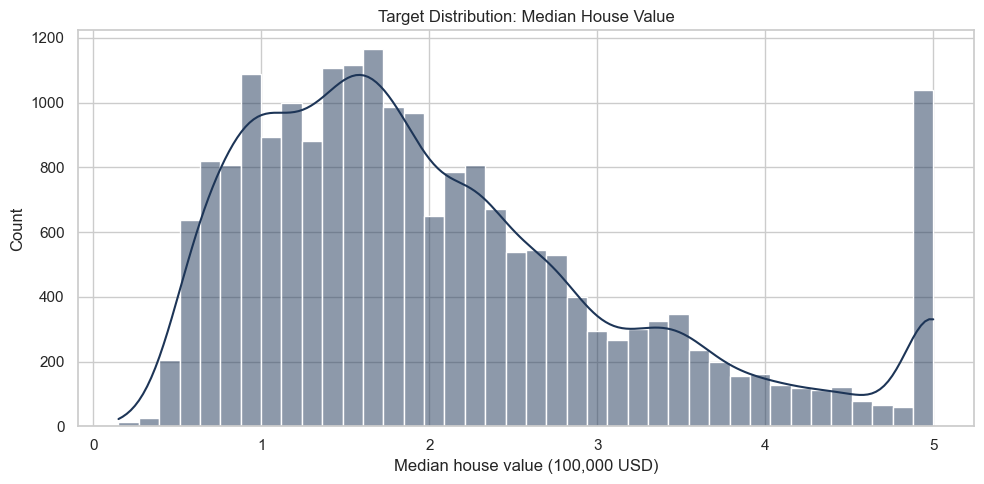

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["median_house_value"], bins=40, kde=True, color="#1d3557", ax=ax)
ax.set_title("Target Distribution: Median House Value")
ax.set_xlabel("Median house value (100,000 USD)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Correlation Heatmap


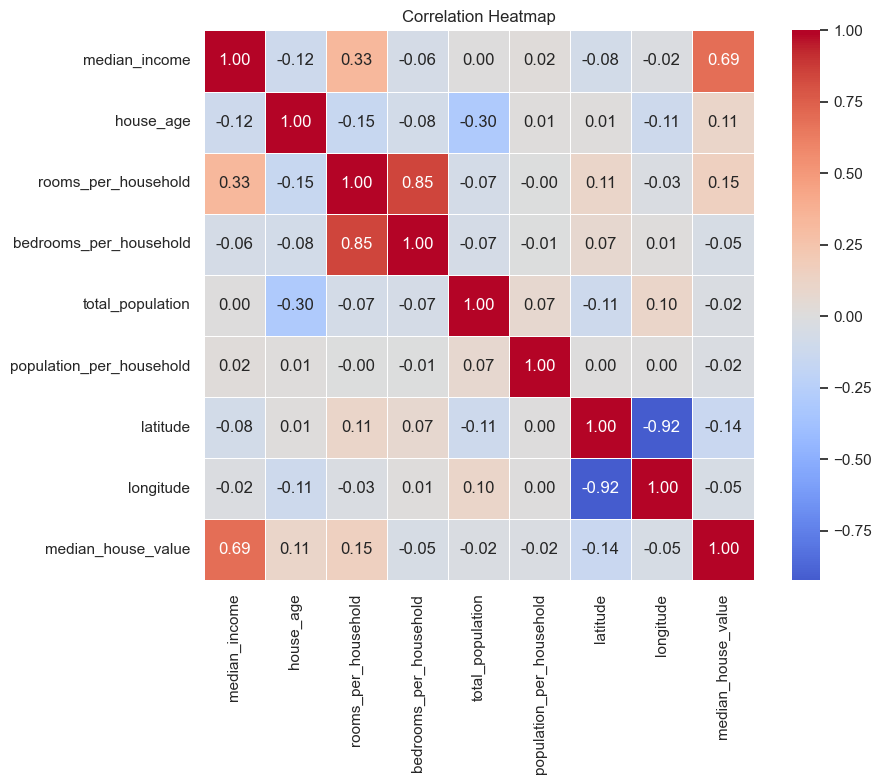

In [4]:
correlation_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax,
)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 3. Latitude / Longitude Scatter Plot Colored by Price


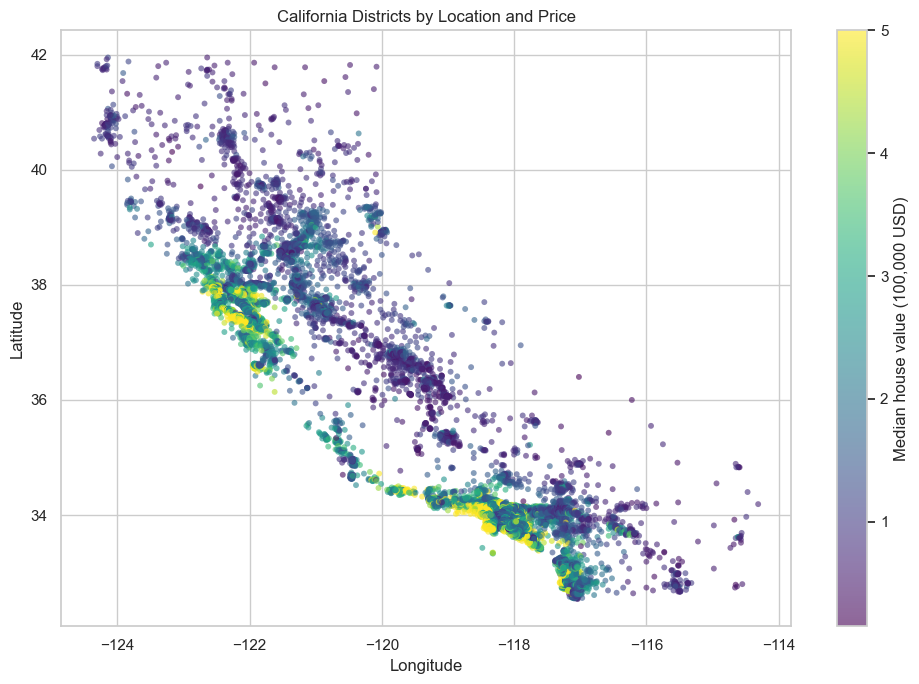

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    s=18,
    alpha=0.6,
    edgecolors="none",
)
colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Median house value (100,000 USD)")
ax.set_title("California Districts by Location and Price")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## 4. Boxplots for the Main Features


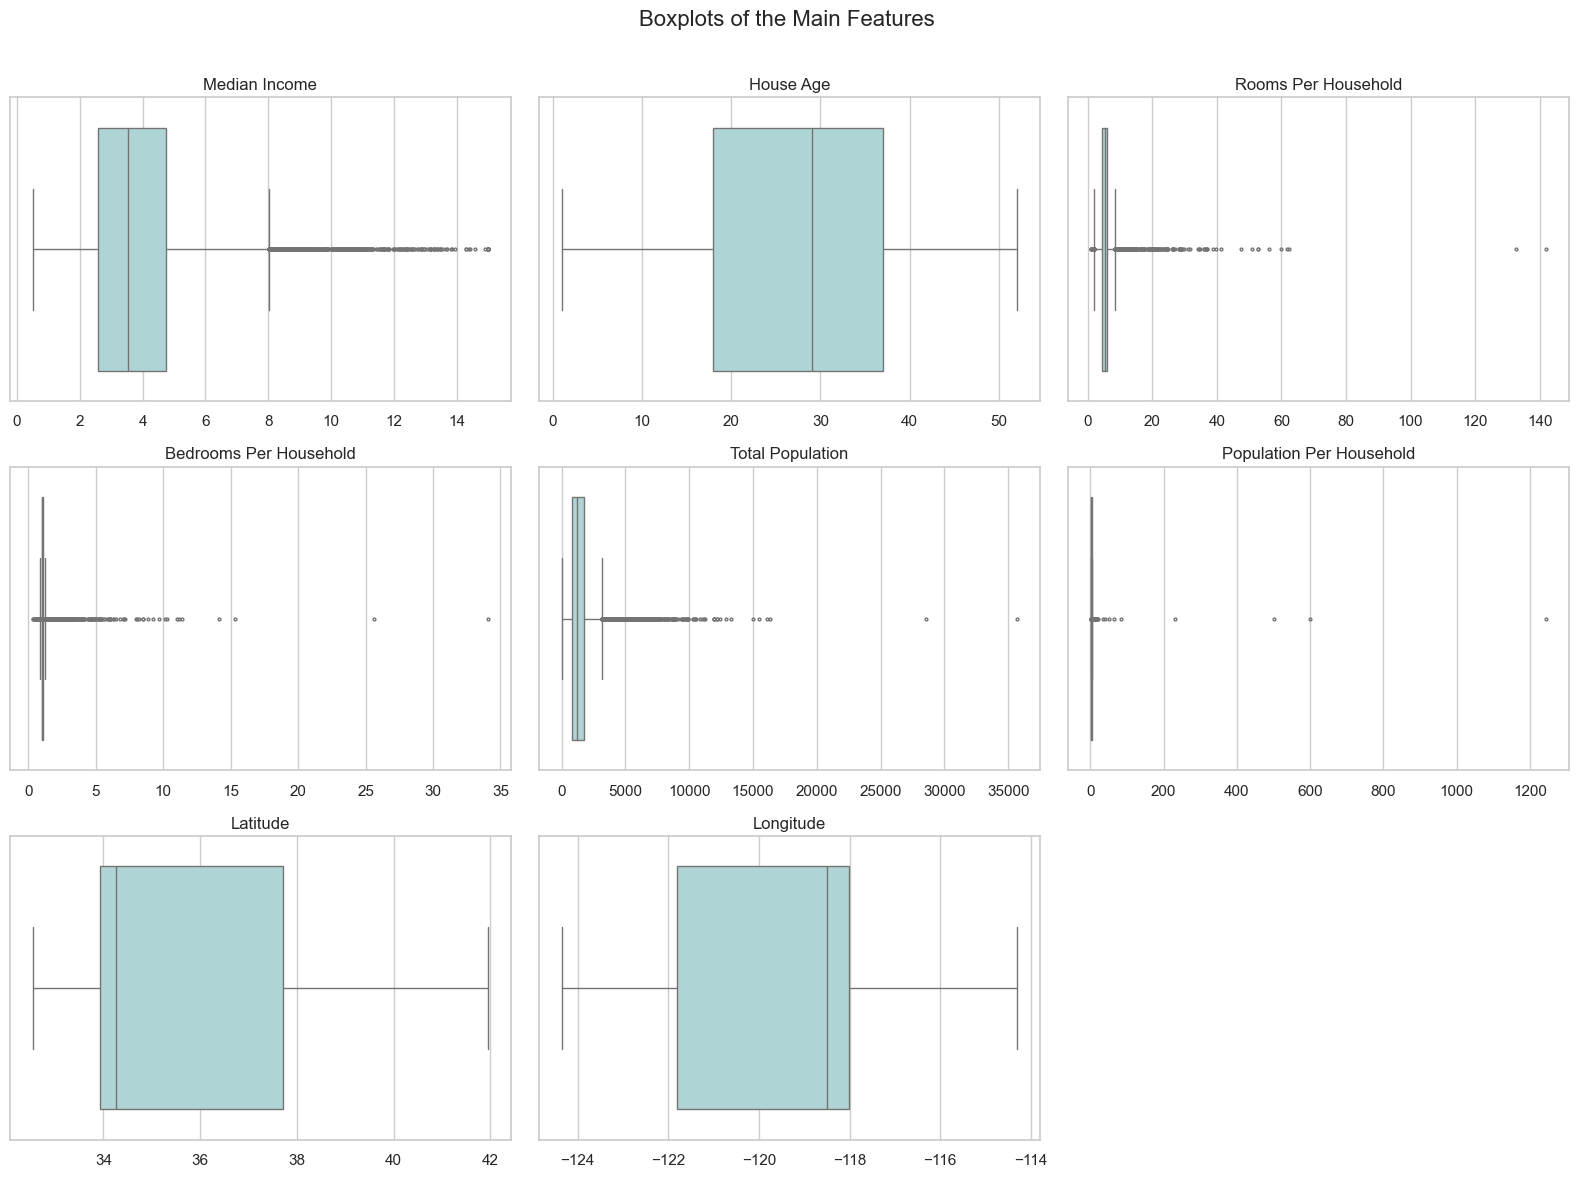

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, column in zip(axes, feature_columns):
    sns.boxplot(x=df[column], ax=ax, color="#a8dadc", fliersize=2)
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")

for ax in axes[len(feature_columns):]:
    ax.axis("off")

fig.suptitle("Boxplots of the Main Features", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## 5. Preprocessing for Modeling

We split the data using an 80/20 train-test split with `random_state=42`. The target stays separate from the input features to avoid leakage.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[feature_columns].copy()
y = df["median_house_value"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


### Feature Engineering

For clarity, the base DataFrame already uses the names `rooms_per_household`, `bedrooms_per_household`, and `population_per_household`. That means the only genuinely new engineered feature we still add here is `bedrooms_ratio`.


In [8]:
def add_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    engineered = dataframe.copy()
    engineered["bedrooms_ratio"] = (
        engineered["bedrooms_per_household"] / engineered["rooms_per_household"]
    )
    return engineered

X_train_engineered = add_engineered_features(X_train)
X_test_engineered = add_engineered_features(X_test)

display(X_train_engineered.head())


,median_income,house_age,rooms_per_household,bedrooms_per_household,total_population,population_per_household,latitude,longitude,bedrooms_ratio
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,0.200576
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,0.232703
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,0.174486
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.258269
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.180940


### Standard Scaling

The scaler is fitted only on the training set and then applied to the test set, which is the correct way to avoid data leakage.


In [9]:
scaler = StandardScaler()

X_train_prepared = pd.DataFrame(
    scaler.fit_transform(X_train_engineered),
    columns=X_train_engineered.columns,
    index=X_train_engineered.index,
)

X_test_prepared = pd.DataFrame(
    scaler.transform(X_test_engineered),
    columns=X_test_engineered.columns,
    index=X_test_engineered.index,
)

print(f"Prepared training shape: {X_train_prepared.shape}")
print(f"Prepared test shape: {X_test_prepared.shape}")
display(X_train_prepared.head())


Prepared training shape: (16512, 9)
Prepared test shape: (4128, 9)


,median_income,house_age,rooms_per_household,bedrooms_per_household,total_population,population_per_household,latitude,longitude,bedrooms_ratio
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,-0.211785
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,0.342185
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,-0.661658
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,0.783032
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,-0.550364


## 6. Modeling

We start with a `LinearRegression` baseline, then compare it with `Ridge`, `DecisionTreeRegressor`, `RandomForestRegressor`, and `GradientBoostingRegressor` using `cross_val_score`. The comparison metric is RMSE, so lower values are better.


In [10]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.tree import DecisionTreeRegressor

X_train_model = X_train_prepared.copy()
X_test_model = X_test_prepared.copy()

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
search_cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)


### Linear Regression Baseline


In [11]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_model, y_train)

linear_predictions = linear_regression.predict(X_test_model)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

baseline_results = pd.DataFrame(
    [
        {
            "model": "LinearRegression",
            "test_rmse": linear_rmse,
            "test_mae": linear_mae,
            "test_r2": linear_r2,
        }
    ]
).round(4)

display(baseline_results)


,model,test_rmse,test_mae,test_r2
0,LinearRegression,0.7292,0.5261,0.5942


### Cross-Validated Model Comparison

We compare the candidate models with 5-fold cross-validation on the training set.


In [12]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=1,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
}

comparison_rows = []

for model_name, model in models.items():
    neg_mse_scores = cross_val_score(
        model,
        X_train_model,
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv_strategy,
        n_jobs=1,
    )
    rmse_scores = (-neg_mse_scores) ** 0.5
    comparison_rows.append(
        {
            "model": model_name,
            "cv_rmse_mean": rmse_scores.mean(),
            "cv_rmse_std": rmse_scores.std(),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("cv_rmse_mean").reset_index(drop=True)
best_model_name = comparison_df.loc[0, "model"]

print(f"Best model from cross-validation: {best_model_name}")
display(comparison_df.round(4))


Best model from cross-validation: RandomForestRegressor


,model,cv_rmse_mean,cv_rmse_std
0,RandomForestRegressor,0.5117,0.0121
1,GradientBoostingRegressor,0.5328,0.0129
2,Ridge,0.7143,0.0135
3,LinearRegression,0.7143,0.0135
4,DecisionTreeRegressor,0.7457,0.0194


### Hyperparameter Tuning on the Best Model

We use `GridSearchCV` for smaller search spaces and `RandomizedSearchCV` for the ensemble models, where a full grid would be unnecessarily expensive.


In [13]:
def build_search(model_name: str):
    if model_name == "Ridge":
        return GridSearchCV(
            estimator=Ridge(),
            param_grid={
                "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
                "fit_intercept": [True, False],
                "solver": ["auto", "svd", "cholesky", "lsqr"],
            },
            scoring="neg_mean_squared_error",
            cv=search_cv_strategy,
            n_jobs=1,
        )

    if model_name == "DecisionTreeRegressor":
        return GridSearchCV(
            estimator=DecisionTreeRegressor(random_state=42),
            param_grid={
                "max_depth": [None, 5, 10, 20, 30],
                "min_samples_split": [2, 5, 10, 20],
                "min_samples_leaf": [1, 2, 4, 8],
            },
            scoring="neg_mean_squared_error",
            cv=search_cv_strategy,
            n_jobs=1,
        )

    if model_name == "RandomForestRegressor":
        return RandomizedSearchCV(
            estimator=RandomForestRegressor(random_state=42, n_jobs=1),
            param_distributions={
                "n_estimators": [100, 200, 300, 500],
                "max_depth": [None, 10, 20, 30, 40],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": [1.0, "sqrt", "log2"],
                "bootstrap": [True, False],
            },
            n_iter=15,
            scoring="neg_mean_squared_error",
            cv=search_cv_strategy,
            random_state=42,
            n_jobs=1,
        )

    if model_name == "GradientBoostingRegressor":
        return RandomizedSearchCV(
            estimator=GradientBoostingRegressor(random_state=42),
            param_distributions={
                "n_estimators": [100, 200, 300, 500],
                "learning_rate": [0.01, 0.03, 0.05, 0.1],
                "max_depth": [2, 3, 4],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "subsample": [0.6, 0.8, 1.0],
                "max_features": [None, "sqrt", "log2"],
            },
            n_iter=20,
            scoring="neg_mean_squared_error",
            cv=search_cv_strategy,
            random_state=42,
            n_jobs=1,
        )

    return None


search = build_search(best_model_name)

if search is None:
    tuned_model = clone(models[best_model_name])
    tuned_model.fit(X_train_model, y_train)
    tuning_method = "No search needed"
    tuning_best_score_rmse = None
    tuning_best_params = {}
else:
    search.fit(X_train_model, y_train)
    tuned_model = search.best_estimator_
    tuning_method = type(search).__name__
    tuning_best_score_rmse = (-search.best_score_) ** 0.5
    tuning_best_params = search.best_params_

print(f"Tuning method: {tuning_method}")
print(f"Best parameters: {tuning_best_params}")
if tuning_best_score_rmse is not None:
    print(f"Best tuning CV RMSE: {tuning_best_score_rmse:.4f}")


Tuning method: RandomizedSearchCV
Best parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': False}
Best tuning CV RMSE: 0.4949


### Final Test-Set Evaluation


In [14]:
final_predictions = tuned_model.predict(X_test_model)
final_rmse = mean_squared_error(y_test, final_predictions) ** 0.5
final_mae = mean_absolute_error(y_test, final_predictions)
final_r2 = r2_score(y_test, final_predictions)

evaluation_rows = [
    {
        "model": "LinearRegression baseline",
        "test_rmse": linear_rmse,
        "test_mae": linear_mae,
        "test_r2": linear_r2,
    }
]

if best_model_name != "LinearRegression":
    evaluation_rows.append(
        {
            "model": f"{best_model_name} final",
            "test_rmse": final_rmse,
            "test_mae": final_mae,
            "test_r2": final_r2,
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows).round(4)
residuals = y_test - final_predictions
selected_model_name = best_model_name

display(evaluation_df)


,model,test_rmse,test_mae,test_r2
0,LinearRegression baseline,0.7292,0.5261,0.5942
1,RandomForestRegressor final,0.4883,0.3181,0.8180


### Diagnostic Plots

These plots help evaluate the final selected model through residual behavior, feature importance, and the relationship between predictions and true values.


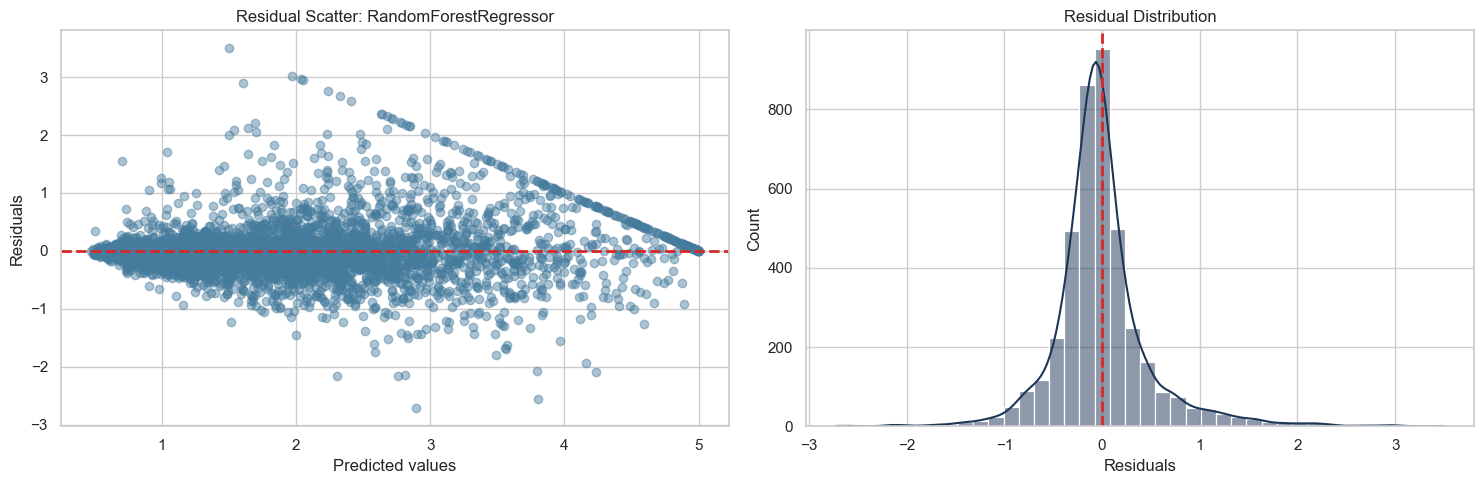

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(final_predictions, residuals, alpha=0.45, color="#457b9d")
axes[0].axhline(0, color="#d62828", linestyle="--", linewidth=2)
axes[0].set_title(f"Residual Scatter: {selected_model_name}")
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Residuals")

sns.histplot(residuals, bins=40, kde=True, color="#1d3557", ax=axes[1])
axes[1].axvline(0, color="#d62828", linestyle="--", linewidth=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


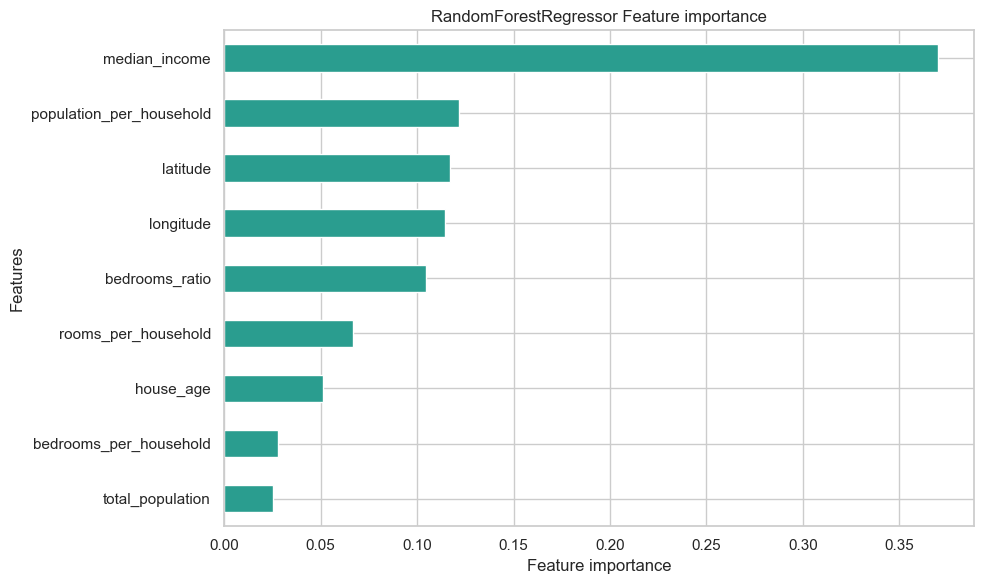

In [16]:
if hasattr(tuned_model, "feature_importances_"):
    importance_values = pd.Series(tuned_model.feature_importances_, index=X_train_model.columns)
    importance_label = "Feature importance"
elif hasattr(tuned_model, "coef_"):
    importance_values = pd.Series(abs(tuned_model.coef_), index=X_train_model.columns)
    importance_label = "Absolute coefficient"
else:
    raise ValueError("The selected model does not expose feature importance information.")

importance_values = importance_values.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
importance_values.plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_title(f"{selected_model_name} {importance_label}")
ax.set_xlabel(importance_label)
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()


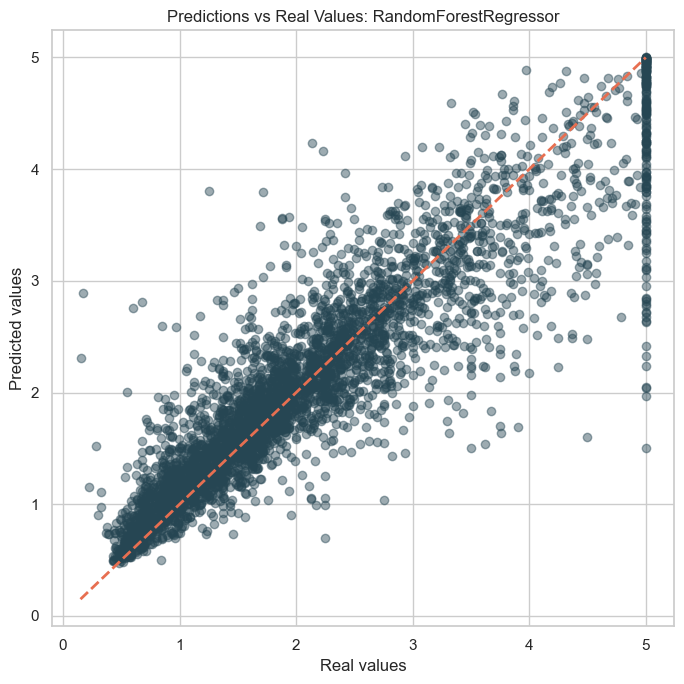

In [17]:
identity_min = min(y_test.min(), final_predictions.min())
identity_max = max(y_test.max(), final_predictions.max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, final_predictions, alpha=0.45, color="#264653")
ax.plot(
    [identity_min, identity_max],
    [identity_min, identity_max],
    color="#e76f51",
    linestyle="--",
    linewidth=2,
)
ax.set_title(f"Predictions vs Real Values: {selected_model_name}")
ax.set_xlabel("Real values")
ax.set_ylabel("Predicted values")
plt.tight_layout()
plt.show()


## 7. Save Artifacts and Predict on New Data

We save the fitted model and the fitted scaler with `joblib`, then define a helper function that takes raw feature values, rebuilds the engineered feature, applies scaling, and returns the predicted house price.


In [18]:
from pathlib import Path

import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "housing_price_model.joblib"
scaler_path = artifacts_dir / "housing_price_scaler.joblib"

joblib.dump(tuned_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")


Model saved to: artifacts\housing_price_model.joblib
Scaler saved to: artifacts\housing_price_scaler.joblib


In [21]:
raw_feature_columns = feature_columns.copy()
model_input_columns = X_train_model.columns.tolist()


def predict_price(features):
    model = joblib.load(model_path)
    fitted_scaler = joblib.load(scaler_path)

    if isinstance(features, dict):
        features_df = pd.DataFrame([features])
    elif isinstance(features, pd.Series):
        features_df = pd.DataFrame([features.to_dict()])
    elif isinstance(features, pd.DataFrame):
        features_df = features.copy()
    else:
        raise TypeError("features must be a dict, pandas Series, or pandas DataFrame")

    missing_columns = [column for column in raw_feature_columns if column not in features_df.columns]
    if missing_columns:
        raise ValueError(f"Missing required features: {missing_columns}")

    features_df = features_df[raw_feature_columns].copy()
    features_engineered = add_engineered_features(features_df)
    features_engineered = features_engineered[model_input_columns]

    features_prepared = pd.DataFrame(
        fitted_scaler.transform(features_engineered),
        columns=model_input_columns,
        index=features_engineered.index,
    )

    predictions = model.predict(features_prepared)
    return pd.Series(predictions, index=features_prepared.index, name="predicted_price")


sample_features = X_test.iloc[[0]].copy()
display(sample_features),
pred=predict_price(sample_features)
display(pred)
pred
print(pred.iloc[0])


,median_income,house_age,rooms_per_household,bedrooms_per_household,total_population,population_per_household,latitude,longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01


20046    0.475699
Name: predicted_price, dtype: float64

0.47569883333333357
